<a href="https://colab.research.google.com/github/david-ehigie/Linux-Projects/blob/main/AI_EthereumFraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORT LIBRARIES**

In [ ]:
# ============================================================
# AI-BASED ETHEREUM FRAUD DETECTION SYSTEM
# GOOGLE COLAB IMPLEMENTATION
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Handling Imbalanced Dataset
from imblearn.over_sampling import SMOTE

# Feature Importance
from sklearn.inspection import permutation_importance

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


**Upload & Load Dataset**

In [ ]:
# ============================================================
# STEP 2 — UPLOAD AND LOAD DATASET
# ============================================================

# Upload dataset from your local computer
from google.colab import files

uploaded = files.upload()

# ============================================================
# LOAD DATASET
# ============================================================

# Replace with your actual uploaded file name
df = pd.read_csv("transaction_dataset.csv")

# Display first 5 rows
df.head()

Saving transaction_dataset.csv to transaction_dataset (1).csv


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

# Replace with your actual uploaded file name
df = pd.read_csv("transaction_dataset.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


**Initial Data Exploration**

In [ ]:
# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\n")

print("Column Names:")
print(df.columns)

print("\n")

print("Dataset Info:")
print(df.info())

print("\n")

print("Missing Values:")
print(df.isnull().sum())

print("\n")

print("Class Distribution:")
print(df['FLAG'].value_counts())

Dataset Shape:
(9841, 51)


Column Names:
Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg min between sent tnx',
       'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' 

**Remove Irrelevant Columns**

In [ ]:
# ============================================================
# STEP 3 — DATA CLEANING & PREPROCESSING
# ============================================================

# ============================================================
# REMOVE IRRELEVANT COLUMNS
# ============================================================

columns_to_drop = ['Unnamed: 0', 'Index', 'Address']

df.drop(columns=columns_to_drop, inplace=True)

print("Irrelevant columns removed successfully.")
print("\n")

print("Remaining Columns:")
print(df.columns)

Irrelevant columns removed successfully.


Remaining Columns:
Index(['FLAG', 'Avg min between sent tnx', 'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time betwee

**REMOVE OBJECT COLUMNS**

In [ ]:
# ============================================================
# REMOVE ALL OBJECT COLUMNS AUTOMATICALLY
# ============================================================

# Find all object/categorical columns
object_columns = df.select_dtypes(include=['object']).columns

print("Object Columns Found:")
print(object_columns)

# Remove them
df.drop(columns=object_columns, inplace=True)

print("\nObject columns removed successfully.")

# ============================================================
# DEFINE FEATURES (X) AND TARGET (y)
# ============================================================

X = df.drop('FLAG', axis=1)

y = df['FLAG']

print("\nFeature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Object Columns Found:
Index([' ERC20 most sent token type', ' ERC20_most_rec_token_type'], dtype='object')

Object columns removed successfully.

Feature Matrix Shape: (9841, 45)
Target Vector Shape: (9841,)


**DEFINE X AND y**

In [ ]:
# ============================================================
# DEFINE FEATURES (X) AND TARGET (y)
# ============================================================

X = df.drop('FLAG', axis=1)

y = df['FLAG']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (9841, 45)
Target Vector Shape: (9841,)


**Train-Test Split**

In [ ]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (7872, 45)
Testing Set Shape: (1969, 45)


**Replace Blank Spaces with NaN**

In [ ]:
# ============================================================
# REPLACE BLANK SPACES WITH NaN
# ============================================================

import numpy as np

X_train = X_train.replace(r'^\s*$', np.nan, regex=True)

X_test = X_test.replace(r'^\s*$', np.nan, regex=True)

print("Blank spaces replaced with NaN successfully.")

Blank spaces replaced with NaN successfully.


**Convert to Numeric**

In [ ]:
# ============================================================
# FORCE ALL FEATURES TO NUMERIC
# ============================================================

import pandas as pd
import numpy as np

# Convert all columns to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')

X_test = X_test.apply(pd.to_numeric, errors='coerce')

print("All non-numeric values converted to NaN.")

All non-numeric values converted to NaN.


**Imputation**

In [ ]:
# ============================================================
# HANDLE MISSING VALUES USING MEDIAN IMPUTATION
# ============================================================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)

print("Missing values handled successfully.")

Missing values handled successfully.


**Scaling**

In [ ]:
# ============================================================
# FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_scaled = scaler.transform(X_test_imputed)

print("Feature scaling completed.")

Feature scaling completed.


**SMOTE**

In [ ]:
# ============================================================
# APPLY SMOTE TO TRAINING DATA ONLY
# ============================================================

from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
FLAG
0    6129
1    1743
Name: count, dtype: int64

After SMOTE:
FLAG
0    6129
1    6129
Name: count, dtype: int64


**Model Training**

Paramete\r	Purpose
n_estimators=200	enough trees for strong learning
max_depth=6	prevents over-complex trees
learning_rate=0.05	stable gradual learning
subsample=0.8	reduces overfitting
colsample_bytree=0.8	feature randomness improves generalization

In [ ]:
# ============================================================
# TRAIN XGBOOST CLASSIFIER
# ============================================================

from xgboost import XGBClassifier

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train_balanced, y_train_balanced)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


**MAKE PREDICTIONS**

In [ ]:
# ============================================================
# MAKE PREDICTIONS
# ============================================================

y_pred = xgb_model.predict(X_test_scaled)

# Prediction probabilities
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed successfully.")

Predictions completed successfully.


In [ ]:
# ============================================================
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC Score:", roc_auc)

print("\nXGBoost Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9817166074149314
Precision: 0.9694835680751174
Recall: 0.9472477064220184
F1-Score: 0.9582366589327146
ROC-AUC Score: 0.9976346074435808

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1533
           1       0.97      0.95      0.96       436

    accuracy                           0.98      1969
   macro avg       0.98      0.97      0.97      1969
weighted avg       0.98      0.98      0.98      1969



**CONFUSION MATRIX**

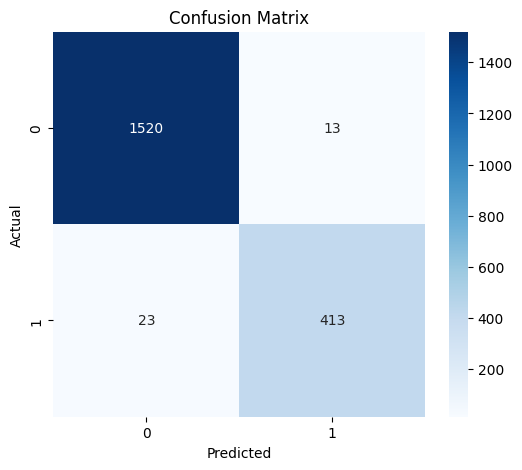

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**FEATURE IMPORTANCE**

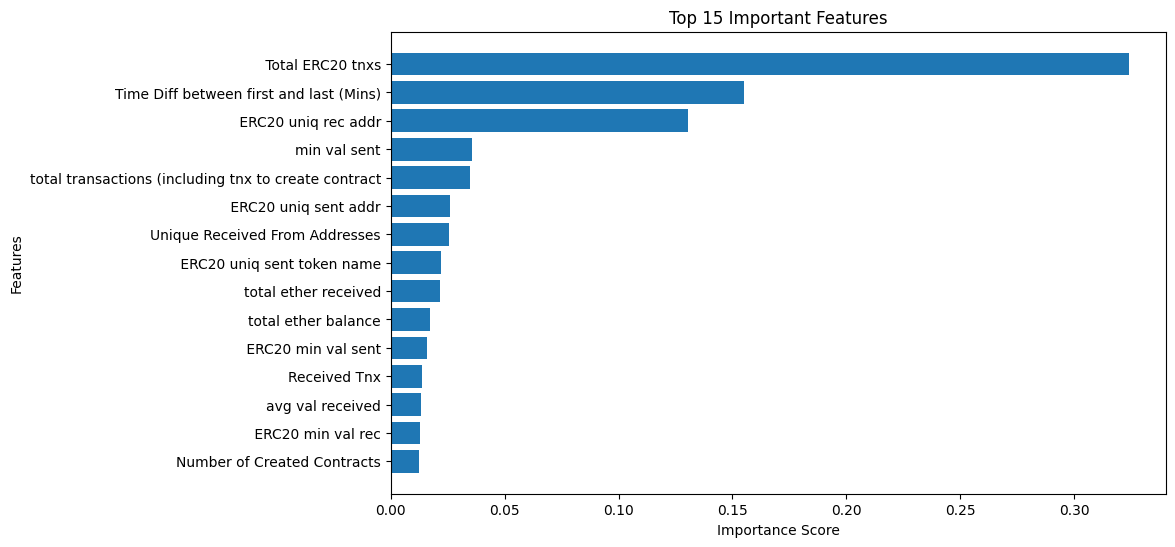

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.show()

**# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================text**

In [ ]:
# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_balanced, y_train_balanced)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# ============================================================
# RANDOM FOREST PREDICTIONS
# ============================================================

y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest predictions completed.")

Random Forest predictions completed.


In [ ]:
# ============================================================
# RANDOM FOREST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance Metrics")
print("----------------------------------")

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance Metrics
----------------------------------
Accuracy : 0.9776536312849162
Precision: 0.9537037037037037
Recall   : 0.944954128440367
F1-Score : 0.9493087557603687
ROC-AUC  : 0.9958856233205862

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1533
           1       0.95      0.94      0.95       436

    accuracy                           0.98      1969
   macro avg       0.97      0.97      0.97      1969
weighted avg       0.98      0.98      0.98      1969



  **CONFUSION MATRIX-----RANDOM FOREST**

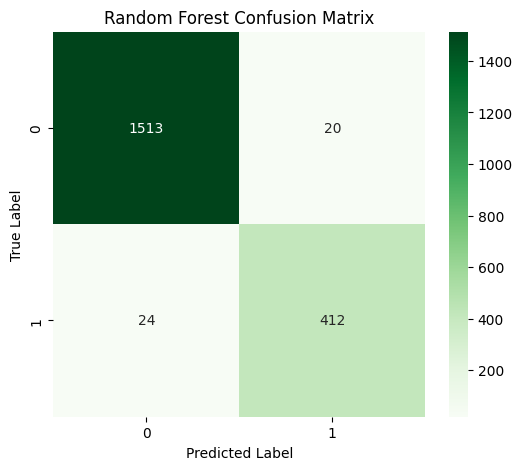

In [ ]:
# ============================================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

**COMPARISON TABLE**

In [ ]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'ROC-AUC'
    ],

    'Random Forest': [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ],

    'XGBoost': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

comparison_df

,Metric,Random Forest,XGBoost
0,Accuracy,0.977654,0.981717
1,Precision,0.953704,0.969484
2,Recall,0.944954,0.947248
3,F1-Score,0.949309,0.958237
4,ROC-AUC,0.995886,0.997635
